In [ ]:
# Création du dossier .kaggle si ce n'est pas déjà fait
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Test : Lister les datasets disponibles
!kaggle datasets list


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.10/dist-packages/kaggle/__init__.py", line 7, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 407, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
# Télécharger le dataset
!kaggle datasets download -d jessicali9530/lfw-dataset

# Décompresser le fichier ZIP
!unzip lfw-dataset.zip -d /content/lfw-dataset


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0022.jpg  
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0023.jpg  
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0024.jpg  
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0025.jpg  
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0026.jpg  
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0027.jpg  
  inflating: /content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/Luiz_Inacio_Lula_da_Silva/Luiz_Inacio_Lula_da_Silva_0028.jpg  
  inf

In [ ]:
import os

dataset_path = '/content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled'

# Vérifiez les dossiers et sous-dossiers
print(f"Contenu de '{dataset_path}':")
print(os.listdir(dataset_path)[:10])  # Affiche les 10 premiers éléments


Contenu de '/content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled':
['Nancy_Kerrigan', 'Damon_Dash', 'Robert_Mueller', 'Tzipora_Obziler', 'Joseph_Hoy', 'Augusto_Pinochet', 'Scott_Peterson', 'Jerry_Rice', 'Maria_Conchita_Alonso', 'Mark_Andrew']


In [ ]:
import os
from PIL import Image
import numpy as np

# Chemin vers le dossier contenant les sous-dossiers
dataset_path = '/content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled'

# Lister les noms des dossiers (chaque dossier correspond à une personne)
people_folders = os.listdir(dataset_path)

# Afficher les 10 premiers noms de personnes
print(f"Contenu du dataset : {people_folders[:10]}")


Contenu du dataset : ['Nancy_Kerrigan', 'Damon_Dash', 'Robert_Mueller', 'Tzipora_Obziler', 'Joseph_Hoy', 'Augusto_Pinochet', 'Scott_Peterson', 'Jerry_Rice', 'Maria_Conchita_Alonso', 'Mark_Andrew']


In [ ]:
import pandas as pd

# Charger les fichiers CSV
matchpairs_dev_train = pd.read_csv('/content/lfw-dataset/matchpairsDevTrain.csv')
mismatchpairs_dev_train = pd.read_csv('/content/lfw-dataset/mismatchpairsDevTrain.csv')

# Fonction pour charger une image
def load_image(image_path):
    image = Image.open(image_path).resize((128, 128))  # Redimensionner à 128x128
    return np.array(image) / 255.0  # Normaliser entre 0 et 1

# Fonction pour créer les paires
def create_pairs(dataframe, is_match, dataset_path):
    pairs = []
    labels = []
    for _, row in dataframe.iterrows():
        # Charger les deux images
        img1_path = os.path.join(dataset_path, row['name'], f"{row['name']}_{row['imagenum1']:04d}.jpg")
        img2_path = os.path.join(dataset_path, row['name'], f"{row['name']}_{row['imagenum2']:04d}.jpg") if is_match else \
                    os.path.join(dataset_path, row['name.1'], f"{row['name.1']}_{row['imagenum2']:04d}.jpg")

        # Vérifier l'existence des fichiers
        if os.path.exists(img1_path) and os.path.exists(img2_path):
            img1 = load_image(img1_path)
            img2 = load_image(img2_path)
            pairs.append((img1, img2))
            labels.append(1 if is_match else 0)

    return np.array(pairs), np.array(labels)

# Créer les paires de matched et mismatched
matched_pairs, matched_labels = create_pairs(matchpairs_dev_train, True, dataset_path)
mismatched_pairs, mismatched_labels = create_pairs(mismatchpairs_dev_train, False, dataset_path)

print(f"Nombre de paires correspondantes : {len(matched_pairs)}")
print(f"Nombre de paires non correspondantes : {len(mismatched_pairs)}")


Nombre de paires correspondantes : 1100
Nombre de paires non correspondantes : 1100


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Lambda
import tensorflow as tf

# Fonction pour construire le modèle
def build_siamese_model(input_shape):
    input = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu')(input)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    return Model(input, x)

# Construire les deux branches
input_shape = (128, 128, 3)
base_model = build_siamese_model(input_shape)

input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

# Comparer les sorties des deux branches
processed_a = base_model(input_a)
processed_b = base_model(input_b)
distance = Lambda(lambda tensors: tf.math.abs(tensors[0] - tensors[1]))([processed_a, processed_b])
output = Dense(1, activation='sigmoid')(distance)

# Créer le modèle
siamese_model = Model(inputs=[input_a, input_b], outputs=output)
siamese_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

siamese_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_2             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 128)            │      7,392,320 │ input_layer_1[0][0],   │
│                           │                        │                │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 128)            │              0 │ functional[0][0],      │
│                           │                        │                │ functional[1][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │            129 │ lambda[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

# Préparer les données
all_pairs = np.concatenate([matched_pairs, mismatched_pairs])
all_labels = np.concatenate([matched_labels, mismatched_labels])

X_train, X_val, y_train, y_val = train_test_split(all_pairs, all_labels, test_size=0.2, random_state=42)

# Séparer les paires en deux entrées
X_train_a, X_train_b = X_train[:, 0], X_train[:, 1]
X_val_a, X_val_b = X_val[:, 0], X_val[:, 1]

# Entraîner le modèle
siamese_model.fit(
    [X_train_a, X_train_b], y_train,
    validation_data=([X_val_a, X_val_b], y_val),
    batch_size=32,
    epochs=4
)


Epoch 1/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 274ms/step - accuracy: 0.5065 - loss: 0.7449 - val_accuracy: 0.5205 - val_loss: 0.6866
Epoch 2/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step - accuracy: 0.6217 - loss: 0.6584 - val_accuracy: 0.5750 - val_loss: 0.6894
Epoch 3/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.7685 - loss: 0.4999 - val_accuracy: 0.5500 - val_loss: 0.7752
Epoch 4/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 274ms/step - accuracy: 0.9429 - loss: 0.2154 - val_accuracy: 0.6205 - val_loss: 0.8725


In [ ]:
# Charger une paire d'images
img1 = matched_pairs[0][0]
img2 = matched_pairs[0][1]

# Prédire
prediction = siamese_model.predict([np.expand_dims(img1, axis=0), np.expand_dims(img2, axis=0)])
print(f"Probabilité que les images soient similaires : {prediction[0][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Probabilité que les images soient similaires : 0.98


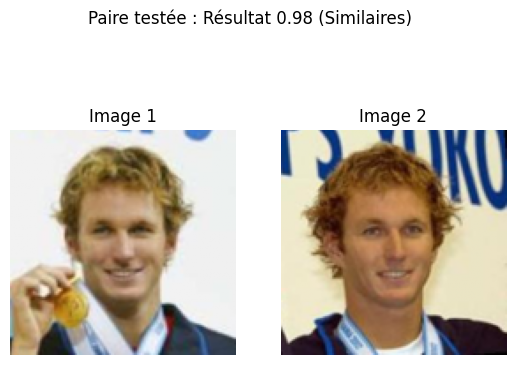

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Visualiser la paire d'images
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis('off')

plt.suptitle("Paire testée : Résultat 0.98 (Similaires)")
plt.savefig("paired_images_result.png")


In [ ]:
# Charger une paire d'images non similaires
img1 = mismatched_pairs[0][0]
img2 = mismatched_pairs[0][1]

# Prédire si les deux images sont similaires
prediction = siamese_model.predict([np.expand_dims(img1, axis=0), np.expand_dims(img2, axis=0)])

# Afficher la probabilité
print(f"Probabilité que les images soient similaires : {prediction[0][0]:.2f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Probabilité que les images soient similaires : 0.02


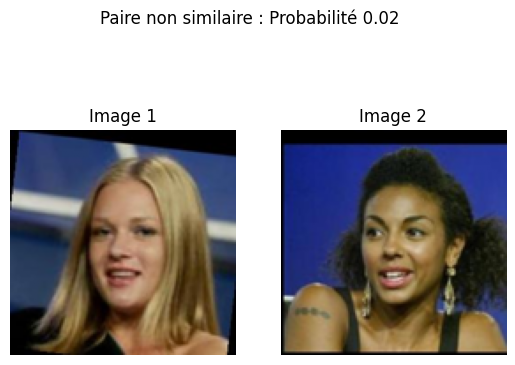

In [ ]:
import matplotlib.pyplot as plt

# Visualiser la paire d'images
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis('off')

plt.suptitle(f"Paire non similaire : Probabilité {prediction[0][0]:.2f}")
plt.savefig("non_similar_pair.png")
plt.show()


In [ ]:
!pip install gender-guesser


In [ ]:
import pandas as pd
from gender_guesser.detector import Detector

# Initialisation du détecteur
detector = Detector()

# Fonction pour deviner le genre à partir du prénom
def guess_gender(name):
    first_name = name.split('_')[0]  # Extraire le prénom avant l'underscore
    gender = detector.get_gender(first_name)
    if gender in ['male', 'mostly_male']:
        return 0  # Homme
    elif gender in ['female', 'mostly_female']:
        return 1  # Femme
    else:
        return None  # Genre inconnu

# Charger les fichiers CSV
people_dev_train = pd.read_csv('/content/lfw-dataset/peopleDevTrain.csv')
people_dev_test = pd.read_csv('/content/lfw-dataset/peopleDevTest.csv')

# Ajouter une colonne `gender` (0 pour Male, 1 pour Female)
people_dev_train['gender'] = people_dev_train['name'].apply(guess_gender)
people_dev_test['gender'] = people_dev_test['name'].apply(guess_gender)

# Supprimer les entrées avec un genre inconnu
people_dev_train = people_dev_train.dropna(subset=['gender'])
people_dev_test = people_dev_test.dropna(subset=['gender'])

print("Données enrichies avec les genres (Male/Female) :")
print(people_dev_train.head())


Données enrichies avec les genres (Male/Female) :
              name  images  gender
1    Aaron_Eckhart       1     0.0
2  Aaron_Patterson       1     0.0
3    Aaron_Peirsol       4     0.0
4       Aaron_Pena       1     0.0
5     Aaron_Sorkin       2     0.0


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [ ]:
# Chemin vers le dossier contenant les images
image_dir = '/content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled'

# Fonction pour charger les images et les étiquettes
def load_images_and_labels(df, image_dir):
    images = []
    labels = []
    for _, row in df.iterrows():
        person_name = row['name']
        num_images = row['images']
        label = int(row['gender'])  # 0 pour Male, 1 pour Female

        for i in range(1, num_images + 1):  # Charger toutes les images de cette personne
            image_path = os.path.join(image_dir, person_name, f"{person_name}_{i:04d}.jpg")
            if os.path.exists(image_path):  # Vérifier si l'image existe
                img = load_img(image_path, target_size=(128, 128))  # Redimensionner l'image
                img_array = img_to_array(img) / 255.0  # Normaliser les pixels
                images.append(img_array)
                labels.append(label)

    return np.array(images), np.array(labels)

# Charger les images et les étiquettes
X_train, y_train = load_images_and_labels(people_dev_train, image_dir)
X_test, y_test = load_images_and_labels(people_dev_test, image_dir)

# Convertir les labels en format one-hot encoding
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

print(f"Images chargées : {X_train.shape}, Labels : {y_train.shape}")


Images chargées : (8679, 128, 128, 3), Labels : (8679, 2)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Construire le modèle CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # 2 sorties : Male et Female
])

# Compiler le modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Afficher le résumé du modèle
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entraîner le modèle
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,  # Ajustez le nombre d'epochs
    batch_size=32,
    verbose=1
)


Epoch 1/4
272/272 ━━━━━━━━━━━━━━━━━━━━ 48s 175ms/step - accuracy: 0.9278 - loss: 0.1998 - val_accuracy: 0.9043 - val_loss: 0.2697
Epoch 2/4
272/272 ━━━━━━━━━━━━━━━━━━━━ 47s 172ms/step - accuracy: 0.9462 - loss: 0.1446 - val_accuracy: 0.9081 - val_loss: 0.2843
Epoch 3/4
272/272 ━━━━━━━━━━━━━━━━━━━━ 47s 171ms/step - accuracy: 0.9558 - loss: 0.1271 - val_accuracy: 0.9078 - val_loss: 0.2875
Epoch 4/4
272/272 ━━━━━━━━━━━━━━━━━━━━ 46s 170ms/step - accuracy: 0.9681 - loss: 0.0971 - val_accuracy: 0.9090 - val_loss: 0.2800


In [ ]:
# Évaluation sur les données de test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9021 - loss: 0.3044
Test Loss: 0.2800, Test Accuracy: 0.9090


In [ ]:
import os

# Dossier de base où les images sont stockées
base_path = "/content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"

# Exemple de prédiction pour une personne spécifique
def predict_gender_for_person(person_name, image_number, model):
    # Construire le chemin de l'image
    image_path = os.path.join(base_path, person_name, f"{person_name}_{image_number:04d}.jpg")

    # Vérifiez si le fichier existe
    if not os.path.exists(image_path):
        print(f"Image introuvable : {image_path}")
        return

    # Charger et prédire le genre
    predict_gender(image_path, model)

# Exemple d'appel
predict_gender_for_person("Aaron_Eckhart", 1, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prédiction : Male (Probabilité : 1.00)


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def predict_gender(image_path, model):
    try:
        # Charger et prétraiter l'image
        img = load_img(image_path, target_size=(128, 128))  # Redimensionner l'image
        img_array = img_to_array(img) / 255.0  # Normalisation
        img_array = np.expand_dims(img_array, axis=0)  # Ajouter une dimension batch

        # Prédire
        prediction = model.predict(img_array)
        gender = 'Male' if np.argmax(prediction) == 0 else 'Female'
        print(f"Prédiction : {gender} (Probabilité : {np.max(prediction):.2f})")
    except Exception as e:
        print(f"Erreur : {e}")


In [ ]:
predict_gender_for_person("Abba_Eban", 1, model)
predict_gender_for_person("Aaron_Guiel", 1, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Prédiction : Male (Probabilité : 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Prédiction : Male (Probabilité : 0.72)


In [ ]:
def predict_gender_for_all_images(person_name, model):
    person_path = os.path.join(base_path, person_name)
    for image_file in os.listdir(person_path):
        image_path = os.path.join(person_path, image_file)
        predict_gender(image_path, model)

# Exemple pour une personne
predict_gender_for_all_images("Aaron_Eckhart", model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Prédiction : Male (Probabilité : 1.00)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


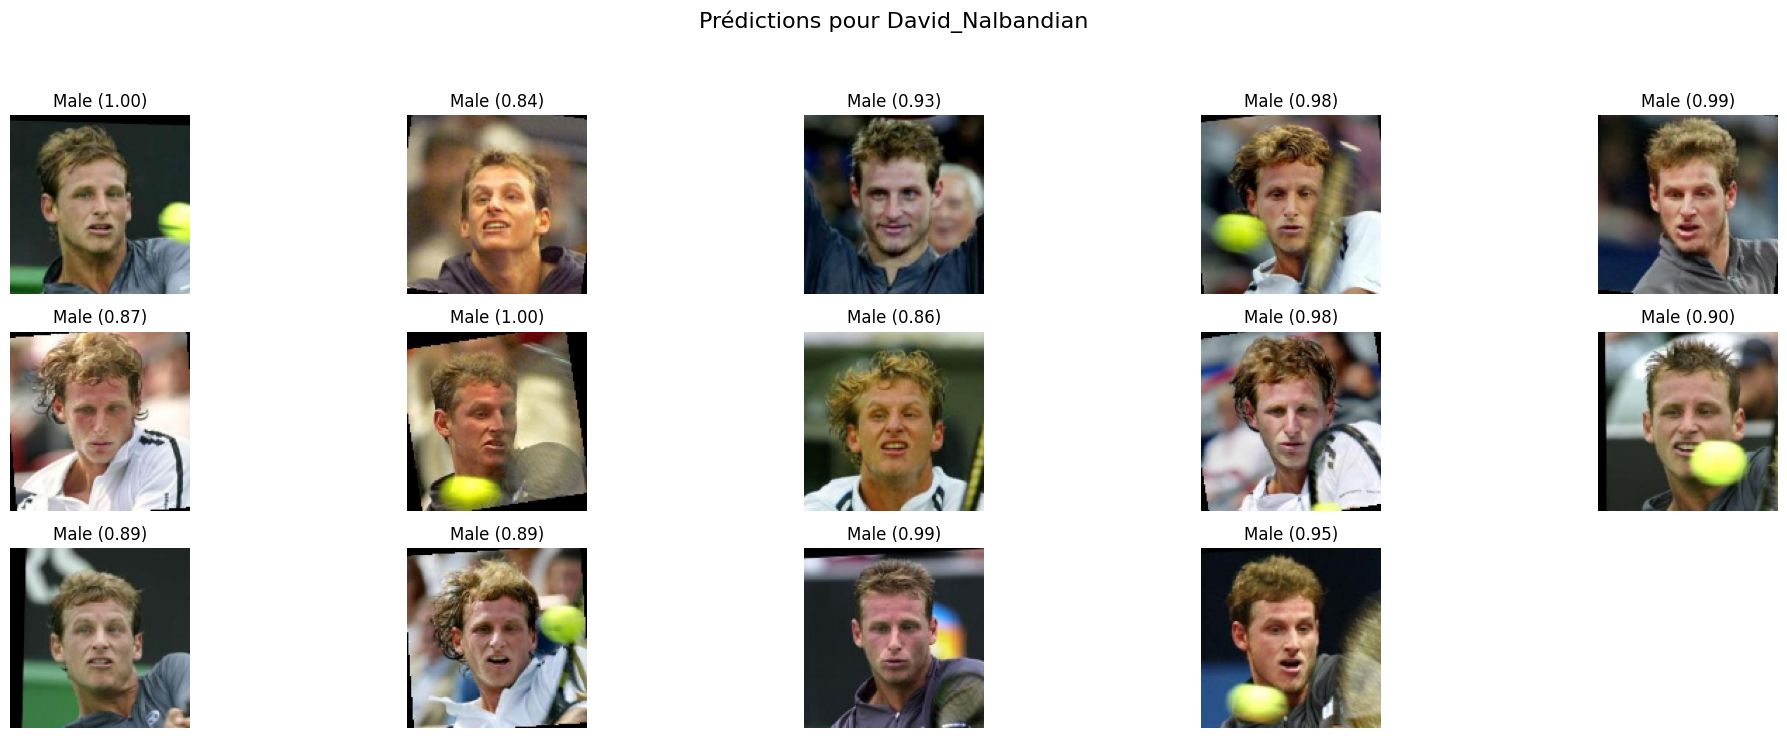

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


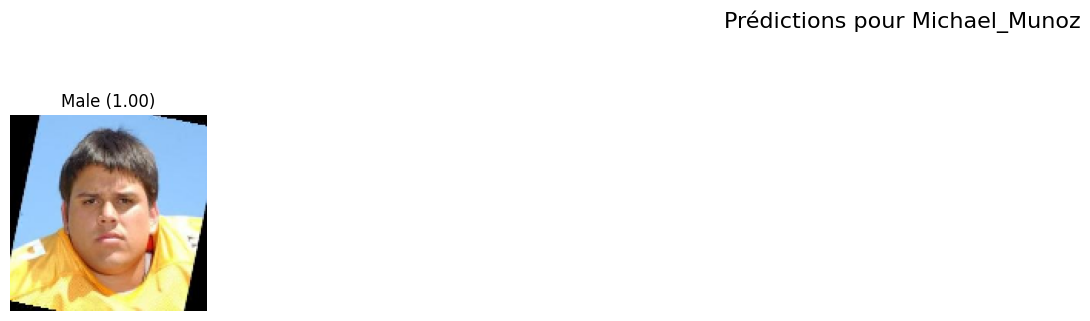

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


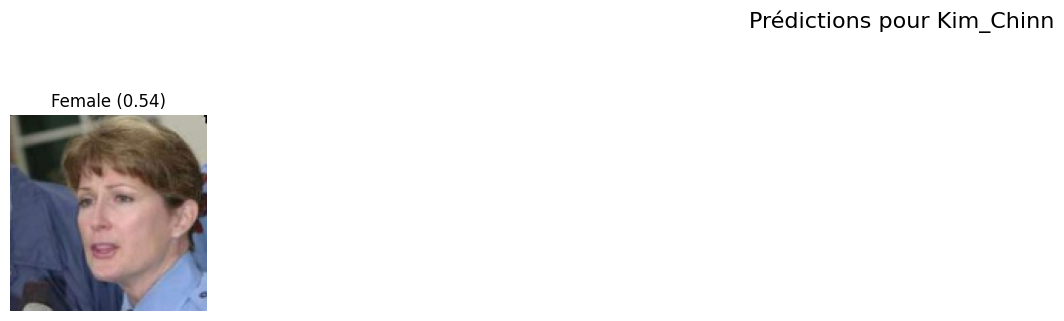

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


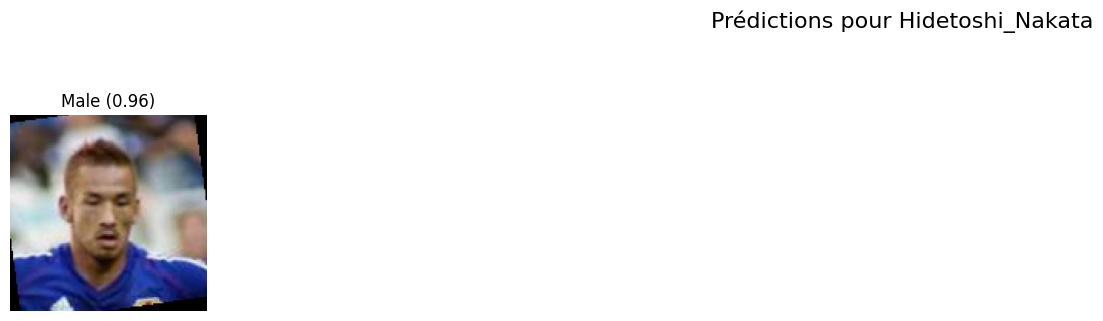

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


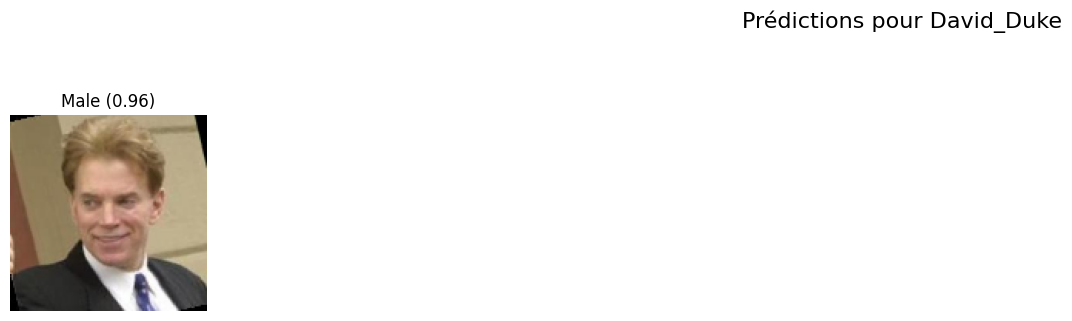

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


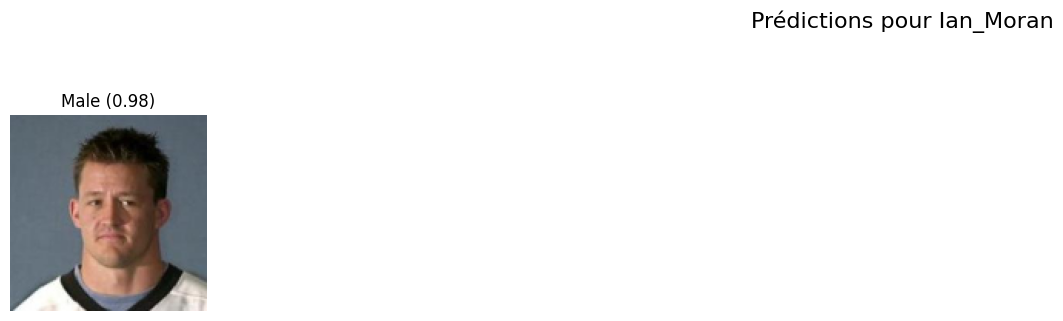

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


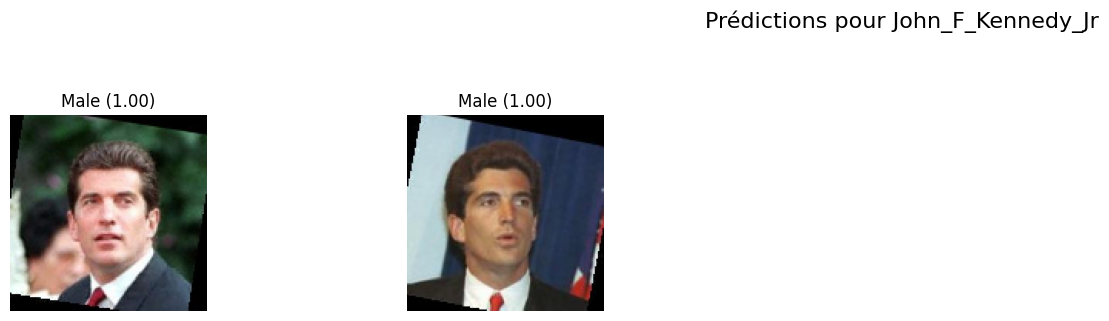

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


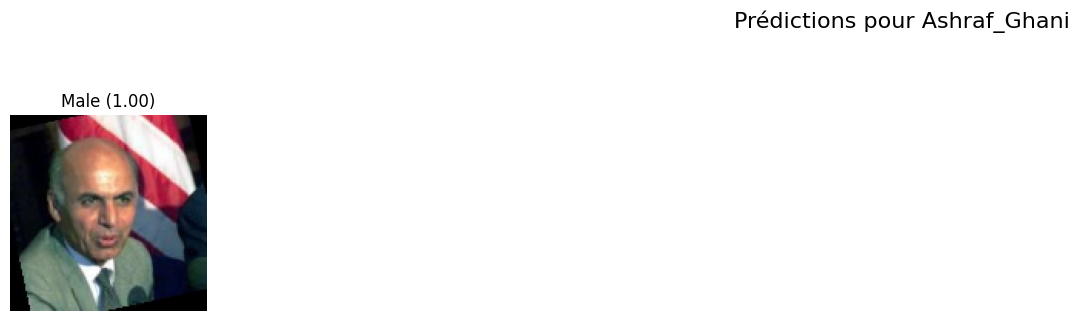

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


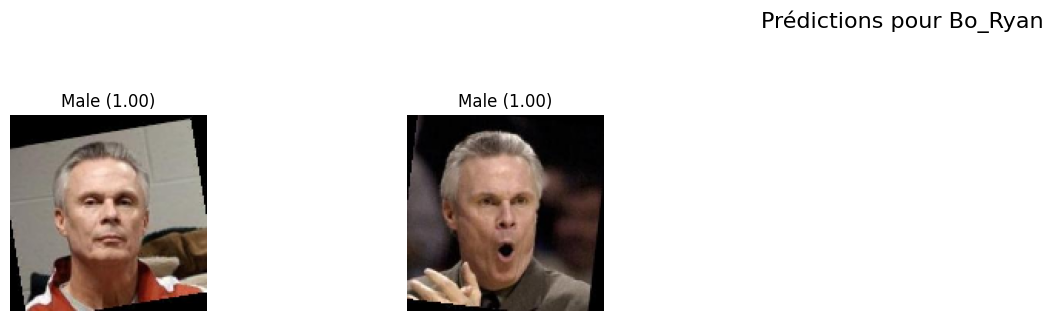

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


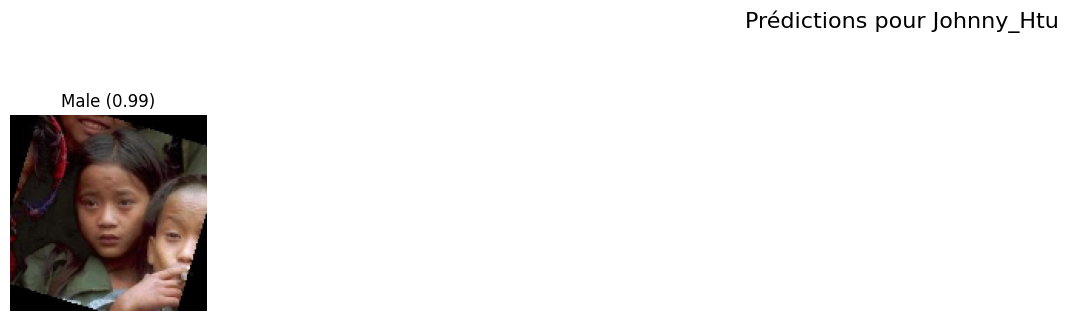

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


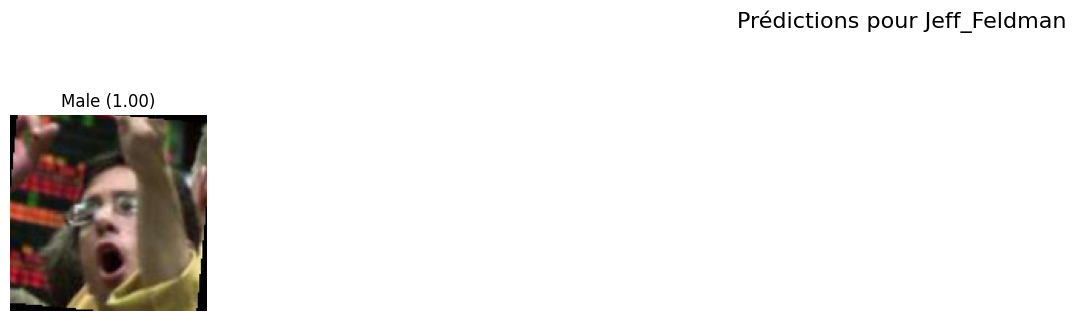

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


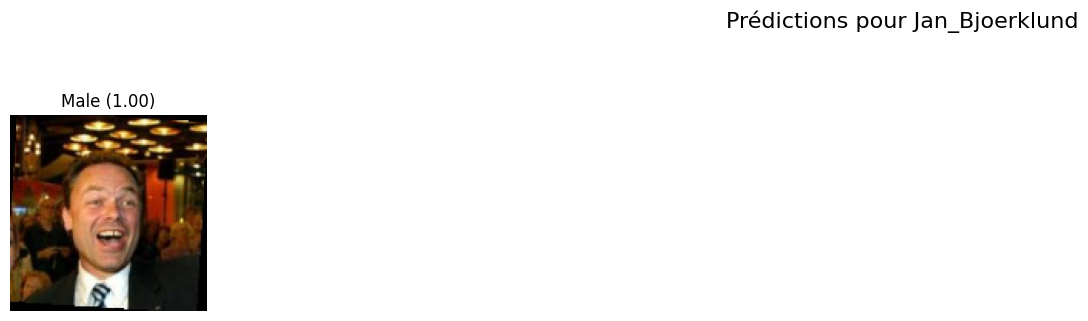

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


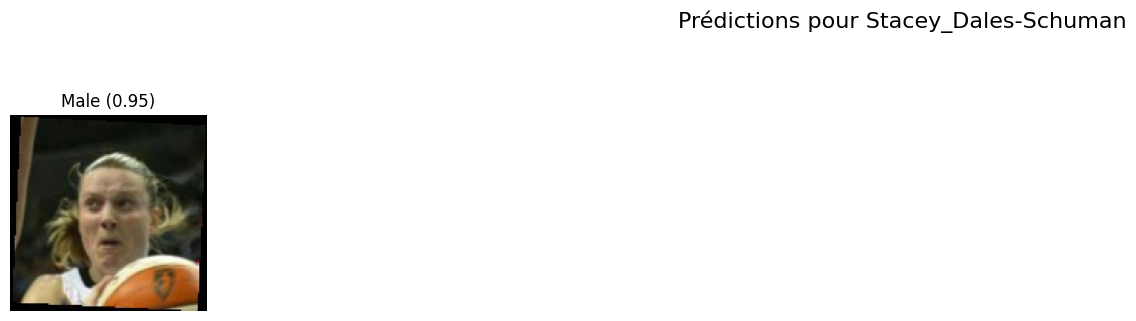

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


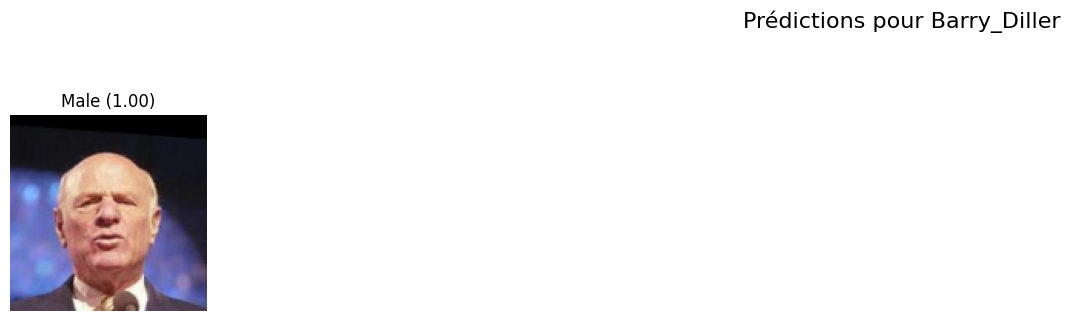

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


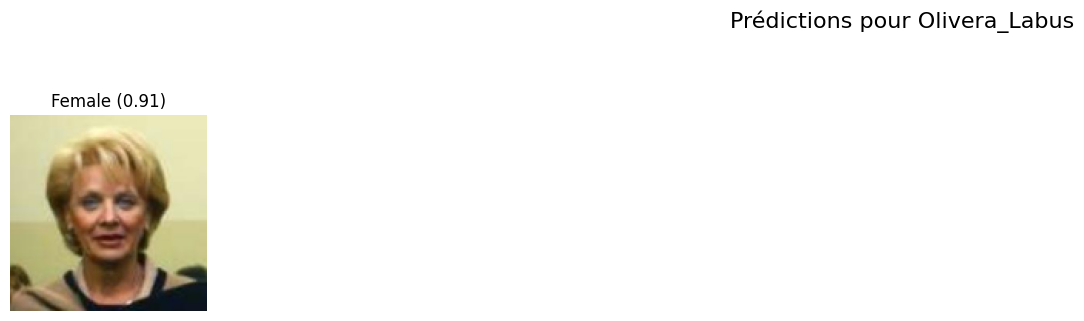

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


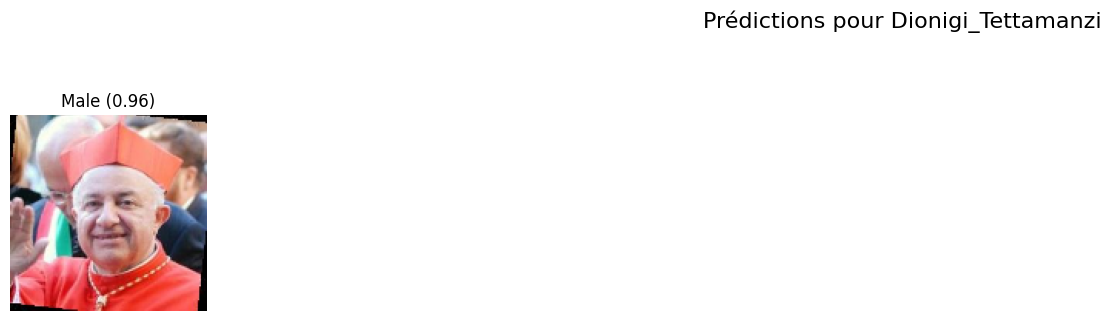

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


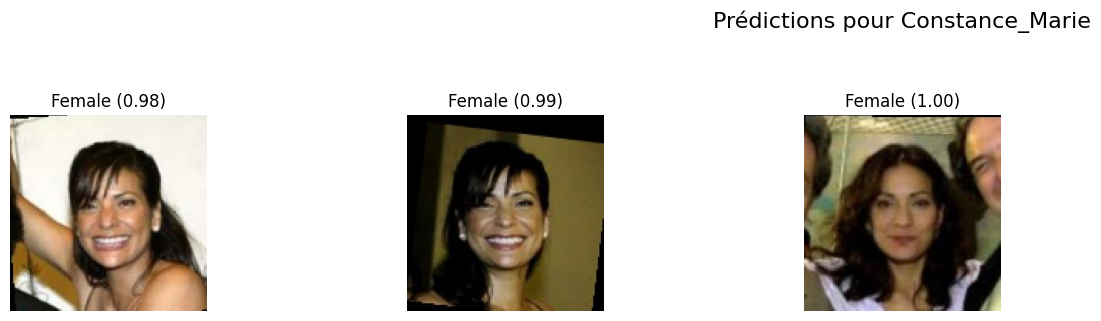

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


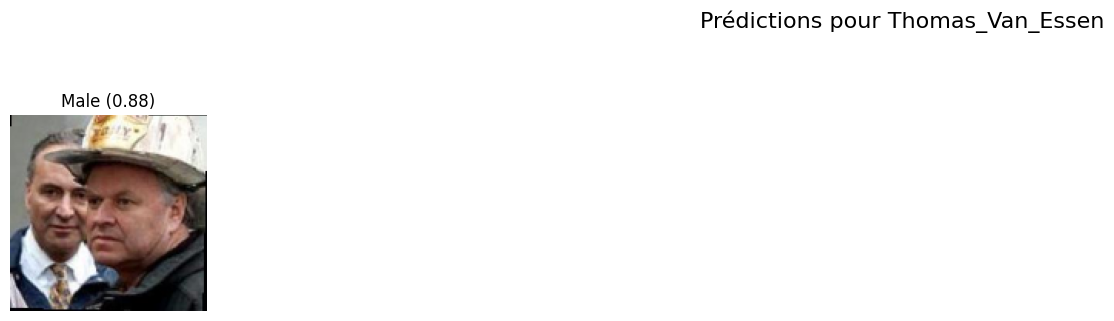

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


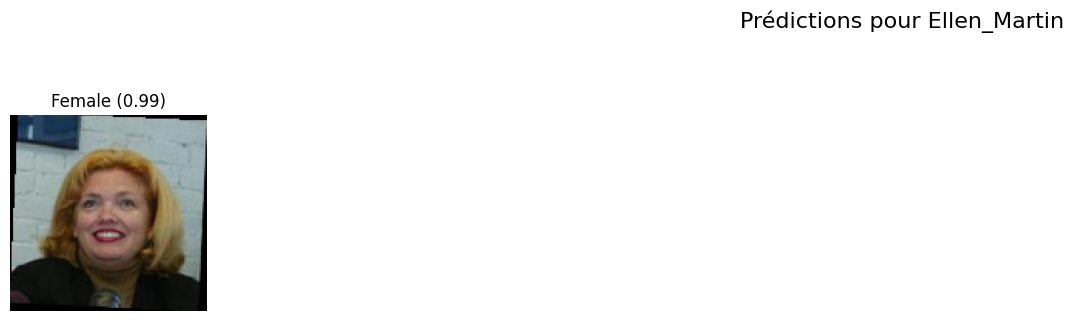

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


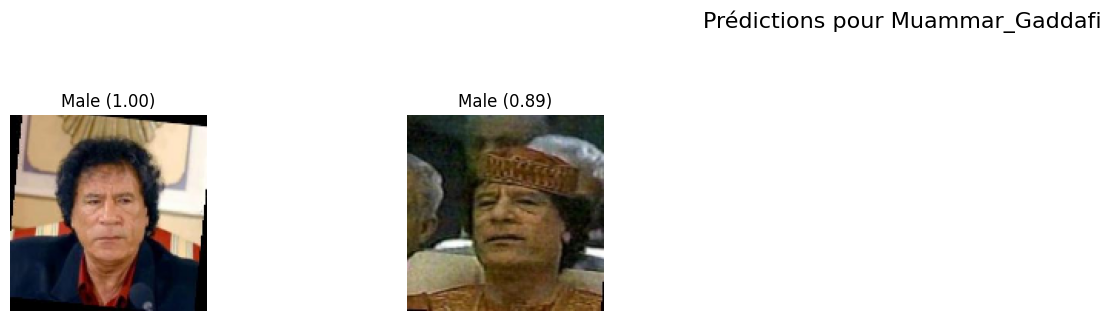

In [72]:
# prompt: comment générer un code pour projeteer les mages des 20 personnes testés

import matplotlib.pyplot as plt
import os
import random

# ... (votre code existant) ...

def predict_and_display_images(person_name, model, num_images=20):
    person_path = os.path.join(base_path, person_name)
    image_files = [f for f in os.listdir(person_path) if f.endswith('.jpg')]

    if not image_files:
        print(f"Aucune image trouvée pour {person_name}")
        return

    num_images = min(num_images, len(image_files))  # Limiter le nombre d'images au nombre disponible
    selected_images = random.sample(image_files, num_images)

    plt.figure(figsize=(20, 10))  # Ajuster la taille de la figure

    for i, image_file in enumerate(selected_images):
        image_path = os.path.join(person_path, image_file)
        try:
            img = load_img(image_path, target_size=(128, 128))
            img_array = img_to_array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            prediction = model.predict(img_array)
            predicted_class_index = np.argmax(prediction)
            gender_labels = ['Male', 'Female', 'Androgynous', 'Unknown']
            gender = gender_labels[predicted_class_index]
            probability = np.max(prediction)

            plt.subplot(4, 5, i + 1)  # Affichage sur une grille 4x5
            plt.imshow(img)
            plt.title(f"{gender} ({probability:.2f})")
            plt.axis('off')
        except Exception as e:
            print(f"Erreur lors du traitement de l'image {image_file}: {e}")

    plt.suptitle(f"Prédictions pour {person_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuster la disposition pour éviter les chevauchements
    plt.show()


# Sélectionner 20 personnes aléatoires pour le test
people_to_test = random.sample(os.listdir("/content/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"), 20)

# Tester sur les 20 personnes sélectionnées
for person_name in people_to_test:
    predict_and_display_images(person_name, model)